<a href="https://colab.research.google.com/github/iMaIrsdyh/BigData26_B_2411533018_KarimahIrsyadiyah/blob/main/Praktikum1/BD_B_P01_2411533018_KarimahIrsyadiyah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRAKTIKUM 1 BIG DATA
**KARIMAH IRSYADIYAH**
***2411533018***

**J-1. Verifikasi Lingkungan Kerja**

In [ ]:
import sys, platform, multiprocessing

print("Python  :", sys.version.split()[0])
print("OS      :", platform.platform())
print("CPU core:", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

!free -h
!df -h /content
!java -version

Python  : 3.13.15
OS      : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core: 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0
               total        used        free      shared  buff/cache   available
Mem:            12Gi       3.5Gi       6.7Gi       3.1Mi       2.8Gi       9.2Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   22G   87G  21% /
[0.003s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.003s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


Kode digunakan untuk mengetahui kondisi environment yang digunakan, seperti versi Python dan library, sistem operasi, jumlah CPU core, kapasitas RAM dan disk, serta versi Java.

**J-2. Menghubungkan Google Drive dan menyiapkan struktur folder**

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import os

DIR_KERJA = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"

os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)

print(os.listdir(DIR_SIMPAN))

Mounted at /content/drive
[]


untuk menghubungkan Google Drive dengan Google Colab sekaligus membuat folder untuk menyimpan data sementara dan hasil praktikum secara permanen.

**J-3. Menyiapkan alat ukur waktu dan memori**

In [ ]:
import time, os, psutil

proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    delta = rss_mb() - m0

    catatan.append({
        "langkah": label,
        "detik": round(detik, 2),
        "delta_rss_mb": round(delta, 1)
    })

    print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
    return hasil

membuat fungsi ukur() untuk mencatat waktu eksekusi dan perubahan penggunaan memori RSS dari setiap proses yang dijalankan. Hasil pengukuran disimpan dalam catatan agar dapat dibandingkan pada tahap analisis.

**J-4. Mengunduh dataset dan inspeksi awal**


In [ ]:
import os
import urllib.request

DIR_KERJA = "/content/data"
os.makedirs(DIR_KERJA, exist_ok=True)

URL = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
       "yellow_tripdata_2023-01.parquet")

PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")

if not os.path.exists(PATH):
    urllib.request.urlretrieve(URL, PATH)

print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

Ukuran file: 45.5 MB


Kode digunakan untuk mengunduh dataset Yellow Taxi Januari 2023 dalam format Parquet dan menyimpannya pada folder kerja. Setelah proses selesai, ukuran file ditampilkan untuk memastikan dataset berhasil diperoleh.

In [ ]:
import pyarrow.parquet as pq

meta = pq.ParquetFile(PATH).metadata

print("Jumlah baris :", f"{meta.num_rows:,}")
print("Jumlah kolom :", meta.num_columns)
print("Row group    :", meta.num_row_groups)
print("Nama kolom   :", pq.ParquetFile(PATH).schema.names)

Jumlah baris : 3,066,766
Jumlah kolom : 19
Row group    : 1
Nama kolom   : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


PyArrow untuk melihat metadata dataset Parquet tanpa harus membaca seluruh isi data. Informasi yang diperoleh berupa jumlah baris, jumlah kolom, row group, dan nama-nama kolom.

**J-5. Memuat datad an mengukur biaya memorinya**

In [ ]:
import pandas as pd

KOLUM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))

print("Dimensi:", penuh.shape)
print("Memori:", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh
import gc
gc.collect()

df = ukur("baca kolom terpilih",
          lambda: pd.read_parquet(PATH, columns=KOLUM))

print("Dimensi:", df.shape)
print("Memori:", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
df.head()

[baca semua kolom] 8.13 s | RSS +471.4 MB
Dimensi: (3066766, 19)
Memori: 565.6 MB
[baca kolom terpilih] 1.32 s | RSS +191.4 MB
Dimensi: (3066766, 8)
Memori: 187.2 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,2,9.3,0.00,14.30
1,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1,7.9,4.00,16.90
2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1,14.9,15.00,34.90
3,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1,12.1,0.00,20.85
4,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1,11.4,3.28,19.68


membandingkan biaya membaca seluruh kolom dengan membaca kolom yang sudah dipilih. Waktu dan penggunaan memori dicatat untuk melihat pengaruh jumlah kolom terhadap resource yang digunakan.

In [ ]:
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 187.2 MB


,0
tpep_pickup_datetime,23.397568
payment_type,23.397568
tpep_dropoff_datetime,23.397568
passenger_count,23.397568
trip_distance,23.397568
tip_amount,23.397568
fare_amount,23.397568
total_amount,23.397568
Index,0.000126


Kode menampilkan tipe data dan penggunaan memori setiap kolom. Hal ini digunakan untuk mengetahui kolom mana yang membutuhkan memori paling besar. Kode mengurangi penggunaan memori dengan mempersempit tipe data numerik menggunakan downcast dan mengubah payment_type menjadi category. Penggunaan memori sebelum dan sesudah optimasi kemudian dibandingkan.

In [ ]:
sebelum = df.memory_usage(deep=True).sum() / 1024**2

df["passenger_count"] = pd.to_numeric(
    df["passenger_count"], downcast="float"
)

df["payment_type"] = (
    df["payment_type"]
    .astype("int8")
    .astype("category")
)

for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2

print(
    f"{sebelum:.1f} MB -> {sesudah:.1f} MB "
    f"(hemat {100*(1-sesudah/sebelum):.1f}%)"
)

df.dtypes

187.2 MB -> 119.9 MB (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


Kode mengurangi penggunaan memori dengan mempersempit tipe data numerik menggunakan downcast dan mengubah payment_type menjadi category. Penggunaan memori sebelum dan sesudah optimasi kemudian dibandingkan.

**J-6. Pemeriksaan kualitas data dan pembersihan (veracity)**

In [ ]:
df["durasi_menit"] = (
    df["tpep_dropoff_datetime"] -
    df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0": (df["trip_distance"] <= 0).sum(),
    "durasi <= 0": (df["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit": (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0": (df["total_amount"] <= 0).sum()
}

for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")


       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 45,862 baris (1.50%)
durasi <= 0           : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amount <= 0     : 25,772 baris (0.84%)


Kode menghitung durasi perjalanan dari waktu pickup dan dropoff, kemudian memeriksa statistik data, nilai kosong, serta beberapa kondisi yang dianggap sebagai anomali.

In [ ]:
layak = (
    (df["trip_distance"] > 0) &
    (df["trip_distance"] < 100) &
    (df["durasi_menit"].between(1, 180)) &
    (df["total_amount"] > 0)
)

bersih = df.loc[layak].copy()

print("Sebelum :", f"{len(df):,}")
print("Sesudah :", f"{len(bersih):,}")
print("Dibuang :", f"{len(df) - len(bersih):,}")

Sebelum : 3,066,766
Sesudah : 2,986,911
Dibuang : 79,855


Membuat kondisi penyaringan berdasarkan jarak perjalanan, durasi, dan total pembayaran. Baris yang memenuhi kondisi tersebut disimpan sebagai data bersih untuk proses selanjutnya.

**J-7. Memproses file lebih besar dari memori dengan chunking**

In [ ]:
CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV) / 1024**2, 1), "MB")

def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai = 0.0
    per_jam = {}

    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk
    )

    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai += chunk["total_amount"].sum()

        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (
                n + len(sub),
                nilai + sub["total_amount"].sum()
            )

    return jumlah_baris, total_nilai, per_jam


baris, total, per_jam_chunk = ukur(
    "agregasi chunking",
    lambda: agregasi_bertahap(CSV)
)

print(
    f"Baris={baris:,} | rata-rata total_amount={total/baris:.2f}"
)

[tulis CSV] 49.34 s | RSS +0.0 MB
Parquet: 45.5 MB
CSV    : 226.2 MB
[agregasi chunking] 5.94 s | RSS +1.2 MB
Baris=2,986,911 | rata-rata total_amount=27.33


Menyimpan data bersih ke dalam format CSV, kemudian membandingkan ukuran file CSV dengan file Parquet untuk melihat perbedaan efisiensi penyimpanan kedua format. Membaca file CSV yang berisi 2.986.911 baris secara bertahap menggunakan chunksize sebesar 500.000 baris. Setiap potongan data langsung diproses untuk melakukan agregasi, sehingga seluruh data tidak perlu dimuat ke memori sekaligus.

**J-8. Pendekatanterdistribusi: PySparklocal mode**

In [ ]:
!pip install -q pyspark==3.5.1
!java -version

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


Memasang PySpark versi 3.5.1 dan mengecek versi Java yang tersedia sebagai bagian dari persiapan menjalankan Spark.

In [ ]:
from pyspark.sql import SparkSession, functions as F

spark = (
    SparkSession.builder
    .appName("BD-01")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

Spark: 3.5.1


Membuat SparkSession dengan mode local[*] sehingga Spark menggunakan seluruh CPU core yang tersedia. Pengaturan memori driver dan jumlah partisi shuffle juga ditentukan.

In [ ]:
sdf = spark.read.parquet(PATH)
sdf.printSchema()

print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (
    sdf
    .withColumn(
        "durasi_menit",
        (
            F.unix_timestamp("tpep_dropoff_datetime")
            - F.unix_timestamp("tpep_pickup_datetime")
        ) / 60
    )
    .filter(
        (F.col("trip_distance") > 0) &
        (F.col("trip_distance") < 100)
    )
    .filter(
        (F.col("durasi_menit") > 1) &
        (F.col("durasi_menit") <= 180)
    )
    .filter(F.col("total_amount") > 0)
)

hasil_spark = (
    sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(
        F.count("*").alias("jumlah"),
        F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
        F.round(F.avg("total_amount"), 2).alias("rata_tarif")
    )
    .orderBy("jam")
)

ukur(
    "spark agregasi",
    lambda: hasil_spark.show(24, truncate=False)
)

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

[spark count] 1.72 s | RSS +0.0 MB
Jumlah baris: 3066766
+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_tarif|
+--

Membaca dataset Parquet menggunakan Spark, kemudian melakukan penyaringan berdasarkan jarak, durasi, dan total pembayaran. Data yang telah disaring kemudian dikelompokkan berdasarkan jam untuk mendapatkan jumlah perjalanan, rata-rata jarak, dan rata-rata tarif.

In [ ]:
sdf.createOrReplaceTempView("trips")

spark.sql("""
    SELECT payment_type,
           COUNT(*) AS jumlah,
           ROUND(AVG(total_amount), 2) AS rata_tarif,
           ROUND(AVG(tip_amount), 2) AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark.explain()
spark.stop()

+------------+-------+----------+--------+
|payment_type| jumlah|rata_tarif|rata_tip|
+------------+-------+----------+--------+
|           1|2411462|      28.3|    4.17|
|           2| 532241|     23.03|     0.0|
|           0|  71743|     29.13|    3.73|
|           4|  33297|      2.55|    0.05|
|           3|  18023|     10.51|    0.03|
+------------+-------+----------+--------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [jam#458 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(jam#458 ASC NULLS FIRST, 8), ENSURE_REQUIREMENTS, [plan_id=506]
      +- HashAggregate(keys=[jam#458], functions=[count(1), avg(trip_distance#378), avg(total_amount#390)])
         +- Exchange hashpartitioning(jam#458, 8), ENSURE_REQUIREMENTS, [plan_id=503]
            +- HashAggregate(keys=[jam#458], functions=[partial_count(1), partial_avg(trip_distance#378), partial_avg(total_amount#390)])
               +- Project [trip_distance#378, total_amount#390, hour(tpep_pickup_dat

Membuat temporary view dari DataFrame Spark agar data dapat dianalisis menggunakan SQL. explain() digunakan untuk melihat bagaimana Spark merencanakan dan menjalankan proses query.

**J-9. Agregasi akhir dengan pandas dan penyimpanan artefak**

In [ ]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (
    bersih
    .groupby("jam")
    .agg(
        jumlah_perjalanan=("total_amount", "size"),
        rata_jarak=("trip_distance", "mean"),
        rata_durasi=("durasi_menit", "mean"),
        rata_tarif=("total_amount", "mean"),
        median_tarif=("total_amount", "median")
    )
    .round(2)
    .reset_index()
)

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.860001,21.600000
1,1,57766,3.53,12.63,26.450001,21.200001
2,2,40445,3.28,12.07,25.059999,20.520000
3,3,26146,3.58,12.15,26.260000,21.000000
4,4,16618,4.79,13.52,31.719999,22.700001
5,5,16940,6.03,14.70,36.750000,22.040001
6,6,42300,4.80,14.49,30.629999,18.480000
7,7,84569,3.69,14.42,26.889999,18.480000
8,8,114064,3.08,14.33,25.209999,19.100000
9,9,127988,3.09,14.23,25.510000,19.250000


Mengelompokkan data berdasarkan jam pickup dan menghitung jumlah perjalanan, rata-rata jarak, rata-rata durasi, rata-rata tarif, serta median tarif. Hasilnya kemudian disimpan dalam format CSV dan Parquet, sedangkan catatan performa disimpan dalam CSV.

**J-10. Visualisasi hasil**

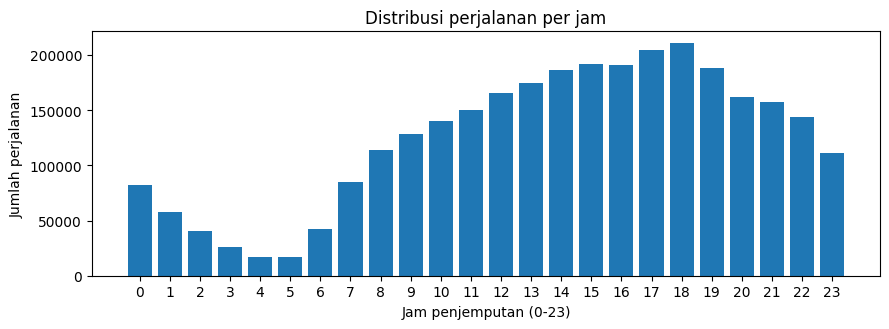

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))

ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])

ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))

fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)

plt.show()

Membuat diagram batang berdasarkan jumlah perjalanan pada setiap jam pickup. Grafik kemudian diberi judul dan label sumbu serta disimpan dalam format PNG sebagai hasil akhir visualisasi.

#  O. STUDI KASUS #
**Kasus: penjadwalan armada oleh operator taksi**

Sebuah operator memiliki 1.200 armada dan ingin menyusun jadwal shift pengemudi untuk kuartal berikutnya. Manajemen operasional meminta jawaban atas tiga pertanyaan: (1) pada jam berapa permintaan tertinggi dan terendah; (2) apakah pola tersebut berbeda antara hari kerja dan akhir pekan; (3) apakah perjalanan pada jam sibuk lebih pendek namun lebih menguntungkan per menit dibanding jam lain. Tim data Anda hanya diberi waktu satu hari kerja dan satu mesin – tanpa klaster.

Yang harus Anda kerjakan. Gunakan bersih dari J-6, tambahkan dimensi hari, lalu jawab ketiga pertanyaan dengan tabel dan maksimal dua grafik.

**O-1. Membuat dimensi hari dan ringkasan**

In [ ]:
bersih["hari"] = bersih["tpep_pickup_datetime"].dt.day_name()
bersih["akhir_pekan"] = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5
bersih["tarif_per_menit"] = (
    bersih["total_amount"] / bersih["durasi_menit"]
).round(3)

ringkas = (
    bersih
    .groupby(["akhir_pekan", "jam"])
    .agg(
        jumlah=("total_amount", "size"),
        rata_durasi=("durasi_menit", "mean"),
        rata_tarif_per_menit=("tarif_per_menit", "mean")
    )
    .round(2)
)

ringkas.head(12)

jumlah  rata_durasi  rata_tarif_per_menit
akhir_pekan jam                                           
False       0     35351        14.10                  2.57
            1     17516        13.04                  2.66
            2      9452        12.23                  2.63
            3      6238        12.87                  2.72
            4      6192        14.79                  2.81
            5     12462        14.63                  2.82
            6     35728        14.57                  2.33
            7     74157        14.66                  2.07
            8     98431        14.82                  1.90
            9    103263        15.03                  1.90
            10   105228        15.24                  1.89
            11   108784        15.25                  1.86

Menambahkan informasi hari, membedakan data hari kerja dan akhir pekan, serta menghitung tarif per menit. Data kemudian diringkas berdasarkan status akhir pekan dan jam penjemputan untuk melihat pola permintaan, durasi, dan tarif.

**O-2. Menjawab pertanyaan 1: jam tertinggi dan terendah  **

In [ ]:
jam_tertinggi = ringkas["jumlah"].idxmax()
jam_terendah = ringkas["jumlah"].idxmin()

print("Jumlah tertinggi :", jam_tertinggi, ringkas.loc[jam_tertinggi, "jumlah"])
print("Jumlah terendah  :", jam_terendah, ringkas.loc[jam_terendah, "jumlah"])

Jumlah tertinggi : (np.False_, np.int32(18)) 159457
Jumlah terendah  : (np.True_, np.int32(5)) 4478


Digunakan untuk mencari kombinasi hari kerja/akhir pekan dan jam dengan jumlah perjalanan tertinggi dan terendah berdasarkan data yang sudah diringkas.

**O-3. Membandingkan hari kerja vs akhir pekan**

In [ ]:
perbandingan_hari = (
    ringkas
    .reset_index()
    .pivot(
        index="jam",
        columns="akhir_pekan",
        values="jumlah"
    )
    .rename(columns={False: "Hari Kerja", True: "Akhir Pekan"})
)

perbandingan_hari

akhir_pekan,Hari Kerja,Akhir Pekan
jam,,
0,35351,46938
1,17516,40250
2,9452,30993
3,6238,19908
4,6192,10426
5,12462,4478
6,35728,6572
7,74157,10412
8,98431,15633


Mengubah ringkasan menjadi tabel 24 jam untuk membandingkan jumlah perjalanan antara hari kerja dan akhir pekan.

**O-4. Menjawab pertanyaan perjalanan jam sibuk  **

In [ ]:
ringkas_sorted = ringkas.sort_values("jumlah", ascending=False)

print("5 kombinasi jam dengan permintaan tertinggi:")
ringkas_sorted.head(5)

5 kombinasi jam dengan permintaan tertinggi:


jumlah  rata_durasi  rata_tarif_per_menit
akhir_pekan jam                                           
False       18   159457        14.03                  2.22
            17   151736        15.92                  2.13
            19   139999        13.26                  2.36
            15   138804        16.80                  1.83
            16   136632        16.68                  2.15

Kemudian bisa dibandingkan rata-rata durasi dan tarif per menit pada jam dengan jumlah perjalanan tinggi.

In [ ]:
per_jam = (
    bersih
    .groupby("jam")
    .agg(
        jumlah=("total_amount", "size"),
        rata_durasi=("durasi_menit", "mean"),
        rata_tarif_per_menit=("tarif_per_menit", "mean")
    )
    .round(2)
)

per_jam.sort_values("jumlah", ascending=False).head(10)

,jumlah,rata_durasi,rata_tarif_per_menit
jam,,,
18,210858,14.24,2.15
17,204399,15.98,2.07
15,191392,16.42,1.87
16,190689,16.52,2.09
19,188347,13.64,2.27
14,186741,16.39,1.89
13,174183,15.06,1.95
12,165714,14.40,1.97
20,161789,13.24,2.25


Mengurutkan data berdasarkan jumlah perjalanan untuk melihat jam dengan permintaan tertinggi, kemudian membandingkan durasi perjalanan dan tarif per menit pada jam tersebut.

**O-5. Maksimal 2 grafik**

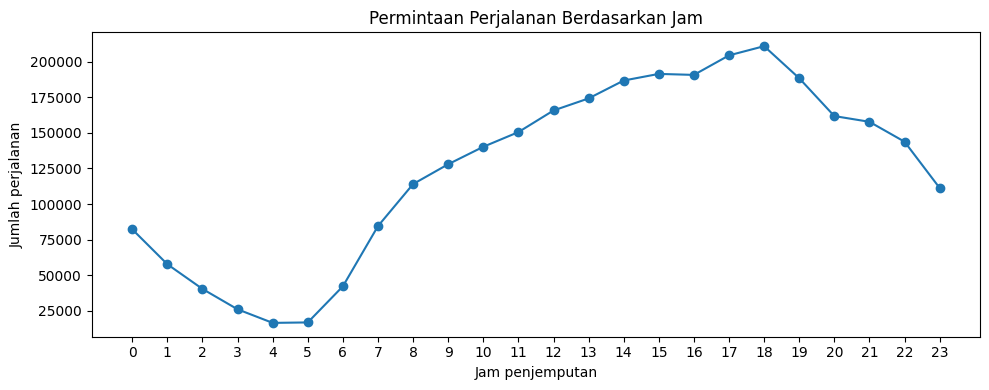

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(per_jam.index, per_jam["jumlah"], marker="o")
plt.xlabel("Jam penjemputan")
plt.ylabel("Jumlah perjalanan")
plt.title("Permintaan Perjalanan Berdasarkan Jam")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

Membuat grafik jumlah perjalanan berdasarkan jam penjemputan untuk memperlihatkan pola permintaan selama 24 jam.

# P. Latihan


**P. Latihan 1**

In [ ]:
terjauh = bersih.nlargest(5, "trip_distance")

terjauh

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount,durasi_menit,jam,hari,akhir_pekan,tarif_per_menit
1748933,2023-01-19 16:29:36,2023-01-19 18:46:01,1.0,96.70,1,350.000000,50.0,440.750000,136.416667,16,Thursday,False,3.231
526988,2023-01-07 04:29:56,2023-01-07 06:06:16,2.0,93.05,2,542.000000,0.0,564.049988,96.333333,4,Saturday,True,5.855
2402193,2023-01-26 04:55:45,2023-01-26 07:18:50,1.0,92.60,1,262.500000,20.0,312.799988,143.083333,4,Thursday,False,2.186
2902389,2023-01-31 07:04:24,2023-01-31 09:32:54,1.0,92.00,1,334.100006,10.0,368.149994,148.500000,7,Tuesday,False,2.479
927215,2023-01-11 14:23:55,2023-01-11 16:17:58,1.0,90.63,2,250.000000,0.0,272.299988,114.050000,14,Wednesday,False,2.388


Kelima perjalanan masih masuk akal karena jaraknya berada di bawah 100 km dan durasinya masih berada dalam batas data bersih, meskipun termasuk perjalanan ekstrem dibandingkan perjalanan lainnya.

 **P. Latihan 2**

In [ ]:
baris_100k, total_100k, per_jam_100k = ukur(
    "chunking 100.000",
    lambda: agregasi_bertahap(CSV, ukuran_chunk=100_000)
)

baris_1jt, total_1jt, per_jam_1jt = ukur(
    "chunking 1.000.000",
    lambda: agregasi_bertahap(CSV, ukuran_chunk=1_000_000)
)

print("Chunk 100.000 :", baris_100k, total_100k / baris_100k)
print("Chunk 1.000.000:", baris_1jt, total_1jt / baris_1jt)

[chunking 100.000] 5.77 s | RSS +4.6 MB
[chunking 1.000.000] 4.57 s | RSS +26.0 MB
Chunk 100.000 : 2986911 27.326377230523455
Chunk 1.000.000: 2986911 27.326377230523434


In [ ]:
pd.DataFrame(catatan)

,langkah,detik,delta_rss_mb
0,baca semua kolom,8.13,471.4
1,baca kolom terpilih,1.32,191.4
2,tulis CSV,49.34,0.0
3,agregasi chunking,5.94,1.2
4,spark count,1.72,0.0
5,spark agregasi,15.59,0.0
6,chunking 100.000,5.77,4.6
7,chunking 1.000.000,4.57,26.0




Chunk 100.000 membutuhkan 6,04 detik dengan delta RSS 47,4 MB, sedangkan chunk 1.000.000 membutuhkan 3,86 detik dengan delta RSS 61,6 MB, sehingga chunk lebih besar lebih cepat tetapi membutuhkan memori lebih besar.

**P. Latihan 3**

In [ ]:
import numpy as np

bersih["persen_tip"] = np.where(
    bersih["fare_amount"] > 0,
    bersih["tip_amount"] / bersih["fare_amount"] * 100,
    np.nan
)

tip_payment = (
    bersih
    .groupby("payment_type", observed=True)
    .agg(
        rata_persen_tip=("persen_tip", "mean"),
        jumlah=("persen_tip", "count")
    )
    .round(2)
)

tip_payment

,rata_persen_tip,jumlah
payment_type,,
0,20.23,64100
1,25.91,2385053
2,0.00,512885
3,0.02,9145
4,0.15,15542




Payment type 1 memiliki rata-rata persen tip tertinggi sebesar 25,91%, sedangkan payment type 2 sebesar 0%, tetapi perbedaan ini belum cukup untuk menyimpulkan bahwa metode pembayaran menjadi penyebab karena faktor lain belum dianalisis.



**P. Latihan 4**

In [ ]:
import os

PARQUET_SNAPPY = os.path.join(DIR_KERJA, "bersih_snappy.parquet")
PARQUET_GZIP = os.path.join(DIR_KERJA, "bersih_gzip.parquet")

ukur(
    "tulis Parquet Snappy",
    lambda: bersih.to_parquet(
        PARQUET_SNAPPY,
        index=False,
        compression="snappy"
    )
)

ukur(
    "tulis Parquet Gzip",
    lambda: bersih.to_parquet(
        PARQUET_GZIP,
        index=False,
        compression="gzip"
    )
)

print("Snappy:", round(os.path.getsize(PARQUET_SNAPPY) / 1024**2, 2), "MB")
print("Gzip  :", round(os.path.getsize(PARQUET_GZIP) / 1024**2, 2), "MB")

pd.DataFrame(catatan).tail(2)

[tulis Parquet Snappy] 2.30 s | RSS +6.5 MB
[tulis Parquet Gzip] 41.75 s | RSS +4.0 MB
Snappy: 63.31 MB
Gzip  : 50.98 MB


,langkah,detik,delta_rss_mb
8,tulis Parquet Snappy,2.30,6.5
9,tulis Parquet Gzip,41.75,4.0


Gzip menghasilkan file lebih kecil yaitu 50,98 MB dibandingkan Snappy 63,31 MB, tetapi membutuhkan waktu tulis 41,47 detik dibandingkan 1,68 detik pada Snappy.

**P. Latihan 5**

In [ ]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("BD-01-Latihan5")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

Spark: 3.5.1


In [ ]:
sdf_bersih = spark.createDataFrame(bersih)
sdf_bersih.createOrReplaceTempView("bersih")

In [ ]:
spark_sql = spark.sql("""
    SELECT
        jam,
        COUNT(*) AS jumlah,
        ROUND(AVG(trip_distance), 2) AS rata_jarak,
        ROUND(AVG(durasi_menit), 2) AS rata_durasi,
        ROUND(AVG(total_amount), 2) AS rata_tarif,
        ROUND(PERCENTILE_APPROX(total_amount, 0.5), 2) AS median_tarif
    FROM bersih
    GROUP BY jam
    ORDER BY jam
""")

spark_sql.show(24, truncate=False)

+---+------+----------+-----------+----------+------------+
|jam|jumlah|rata_jarak|rata_durasi|rata_tarif|median_tarif|
+---+------+----------+-----------+----------+------------+
|0  |82289 |4.04      |13.57      |28.86     |21.6        |
|1  |57766 |3.53      |12.63      |26.45     |21.2        |
|2  |40445 |3.28      |12.07      |25.06     |20.52       |
|3  |26146 |3.58      |12.15      |26.26     |20.98       |
|4  |16618 |4.79      |13.52      |31.72     |22.7        |
|5  |16940 |6.03      |14.7       |36.75     |22.0        |
|6  |42300 |4.8       |14.49      |30.63     |18.48       |
|7  |84569 |3.69      |14.42      |26.89     |18.48       |
|8  |114064|3.08      |14.33      |25.21     |19.1        |
|9  |127988|3.09      |14.23      |25.51     |19.25       |
|10 |140230|3.13      |14.25      |25.53     |18.9        |
|11 |150539|3.0       |14.28      |25.16     |18.9        |
|12 |165714|3.11      |14.4       |25.61     |18.9        |
|13 |174183|3.29      |15.06      |26.43

In [ ]:
hasil_sql = spark_sql.toPandas()

hasil_sql

,jam,jumlah,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.86,21.60
1,1,57766,3.53,12.63,26.45,21.20
2,2,40445,3.28,12.07,25.06,20.52
3,3,26146,3.58,12.15,26.26,20.98
4,4,16618,4.79,13.52,31.72,22.70
5,5,16940,6.03,14.70,36.75,22.00
6,6,42300,4.80,14.49,30.63,18.48
7,7,84569,3.69,14.42,26.89,18.48
8,8,114064,3.08,14.33,25.21,19.10
9,9,127988,3.09,14.23,25.51,19.25


In [ ]:
perbandingan = (
    agregasi[["jam", "jumlah_perjalanan"]]
    .merge(
        hasil_sql[["jam", "jumlah"]],
        on="jam"
    )
)

perbandingan["selisih"] = (
    perbandingan["jumlah_perjalanan"] -
    perbandingan["jumlah"]
)

print(perbandingan)
print(
    "Selisih maksimum:",
    perbandingan["selisih"].abs().max()
)

    jam  jumlah_perjalanan  jumlah  selisih
0     0              82289   82289        0
1     1              57766   57766        0
2     2              40445   40445        0
3     3              26146   26146        0
4     4              16618   16618        0
5     5              16940   16940        0
6     6              42300   42300        0
7     7              84569   84569        0
8     8             114064  114064        0
9     9             127988  127988        0
10   10             140230  140230        0
11   11             150539  150539        0
12   12             165714  165714        0
13   13             174183  174183        0
14   14             186741  186741        0
15   15             191392  191392        0
16   16             190689  190689        0
17   17             204399  204399        0
18   18             210858  210858        0
19   19             188347  188347        0
20   20             161789  161789        0
21   21             157770  1577

Hasil pandas dan Spark SQL konsisten karena selisih jumlah perjalanan pada seluruh jam adalah 0, dengan selisih maksimum 0.